# Regression Models

In this notebook, we build machine learning models to predict the flight ticket price (`price`).

Since the target variable is continuous, this is a regression problem.

We will test different algorithms and compare their performance to select the best model.

## Problem Definition

The goal is to predict the flight ticket price based on several features such as:

- Airline
- Class
- Duration
- Number of stops
- Days left before departure
- Departure and arrival time
- Source and destination cities

Target variable: `price`

In [29]:
# basic imports
import pandas as pd
import numpy as np

# data preprocessing and modeling
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# visualization for model comparison
import matplotlib.pyplot as plt



In [30]:
# load the cleaned dataset
df = pd.read_csv("../data/cleaned/flight_data.csv")

df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
2,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
3,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
4,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955


In [31]:
# for faster training, we will use a sample of the data
df_sample = df.sample(50000, random_state=42)

# separate features and target variable
X = df_sample.drop("price", axis=1)
# target variable
y = df_sample["price"]

In [32]:
# identify categorical and numerical columns
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='str')
Numerical columns: Index(['duration', 'days_left'], dtype='str')


C:\Users\flori\AppData\Local\Temp\ipykernel_30832\1811813649.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [33]:
# define transformers for numerical and categorical features

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# for categorical features, we will use one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [35]:
# define models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=30,
        max_depth=10,
        n_jobs=-1
    )
}

In [36]:
results = []

# evaluate each model
for i, (name, model) in enumerate(models.items(), start=1):
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

print("\nEvaluation completed.")

# create a DataFrame to display results
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df


Evaluation completed.


,Model,MAE,RMSE,R2
0,Linear Regression,4402.260766,6400.677815,0.921476
1,Decision Tree,1362.625450,3674.558399,0.974120
2,Random Forest,2513.646972,4527.008343,0.960720


In [37]:
# identify the best model based on RMSE
best_model_name = results_df.sort_values(by="RMSE").iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Decision Tree


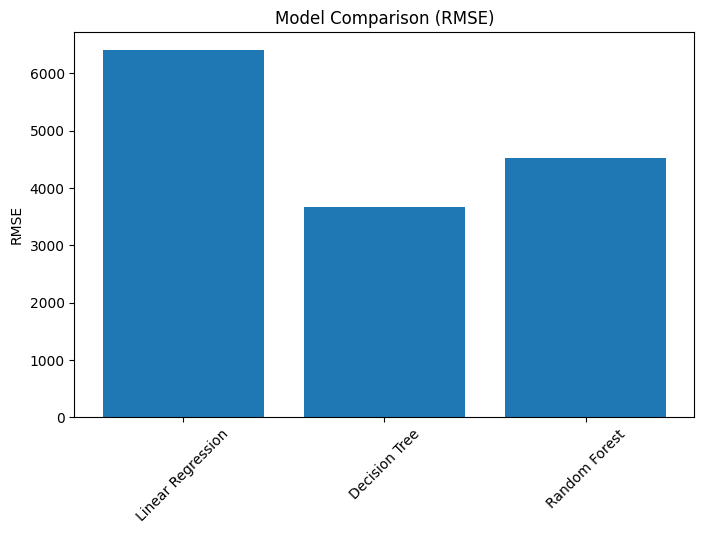

In [38]:
import matplotlib.pyplot as plt

# visualize the results

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)

plt.show()

## Conclusion

The Decision Tree Regressor achieved the best performance among all tested models, with the lowest RMSE and highest R² score.

This suggests that non-linear relationships play an important role in predicting flight ticket prices.

Random Forest also performs well but is slightly less accurate under the current hyperparameter settings.

Linear Regression shows the lowest performance, confirming that the relationship between features and price is not purely linear.